# **Non-linear Classifiers**
## The Impact of Class Imbalance on Non-linear Classifers
### Research Question: How does class imbalance affect non-linear classifiers, which metrics best capture this impact, and which mitigation strategies most effectively improve their performance?
### **Mentor**: Miss Barbora Barancikova
### **Students**: Caleb Arodu and Idarabong Jumbo


This Colab explores how class imbalance influences the performance of non-linear classifiers, identifies the metrics most sensitive to imbalance, and evaluates multiple strategies for mitigating these issues.

We used the credit card fraud dataset from kaggle. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation due to confidentiality issues.

We made use of three classifiers which are Support Vector Machine(SVM), Decision Tree, and Random Forest.

The performance metrics explored were accuracy, precision, recall and f1-score.

We evaluated the models on four settings: the original imbalanced dataset, a randomly undersampled dataset, a SMOTE-oversampled dataset, and a combined approach where each of these datasets was trained with cost-weighting (cost-sensitive learning).



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Downloading the Dataset

In [ ]:
import gdown

file_id = "1npC6GIraFauLtnHJG0RKEll5zTsXZGlS"
url = f"https://drive.google.com/uc?id={file_id}"
output = "creditcard.csv"
gdown.download(url, output, quiet=False)

data = pd.read_csv(output)


Downloading...
From (original): https://drive.google.com/uc?id=1npC6GIraFauLtnHJG0RKEll5zTsXZGlS
From (redirected): https://drive.google.com/uc?id=1npC6GIraFauLtnHJG0RKEll5zTsXZGlS&confirm=t&uuid=3c29675a-80da-4a7f-acda-36885d88a81f
To: /content/creditcard.csv
100%|██████████| 151M/151M [00:25<00:00, 6.00MB/s]


### **Data Exploration and Visualization**

In [ ]:
pd.options.display.max_columns = None # To be able to see all the columns of the dataset irrespective of the length

In [ ]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
data.shape

(284807, 31)

In [ ]:
data.isnull().sum() # To check if there is any null value in the dataset

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


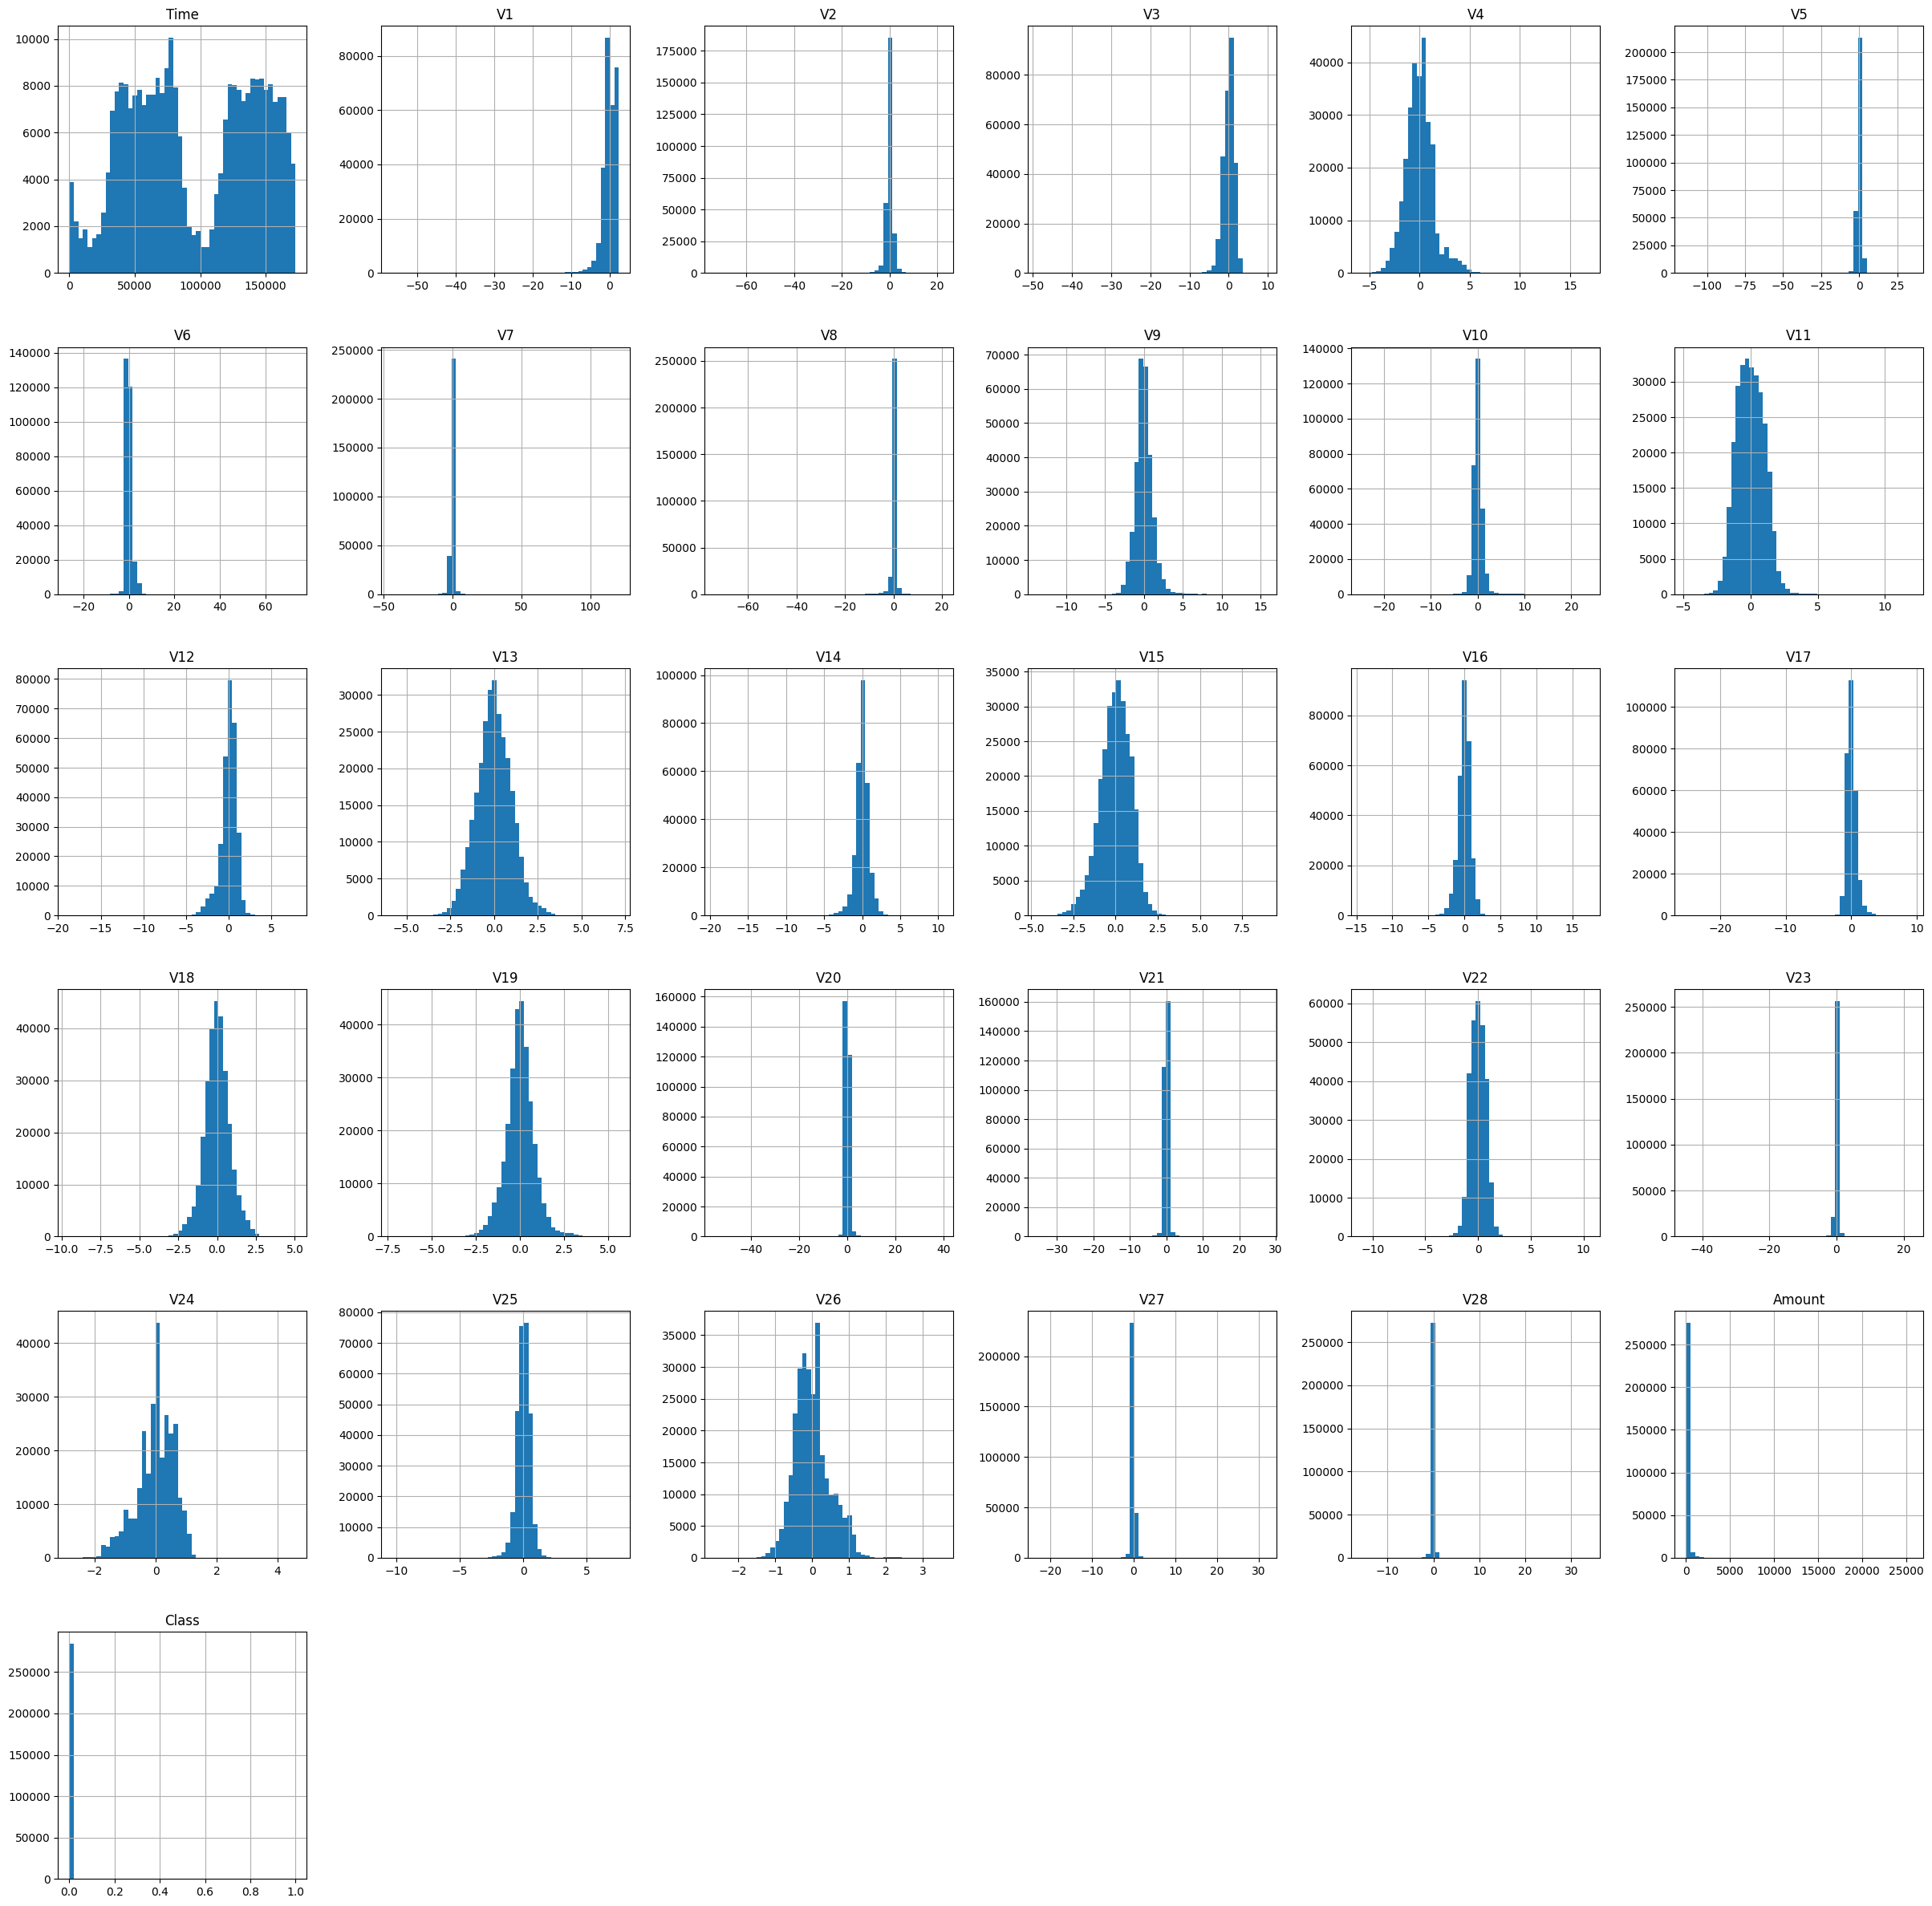

In [ ]:
data.hist(bins=50, figsize=(30,30))
plt.show()

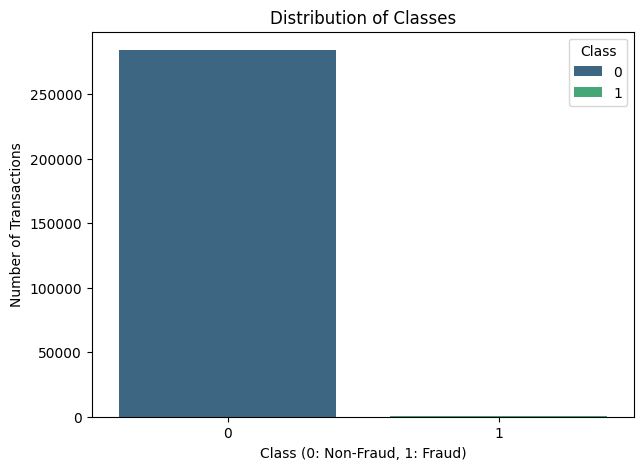

In [ ]:
class_counts = data["Class"].value_counts()
palette = sns.color_palette("viridis", n_colors=2)

# Plot the bar chart with the custom palette
plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette, hue=class_counts.index)

plt.title("Distribution of Classes")
plt.xlabel("Class (0: Non-Fraud, 1: Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(ticks=[0, 1], labels=["0", "1"], rotation=0) # Ensure labels are clear
plt.show()

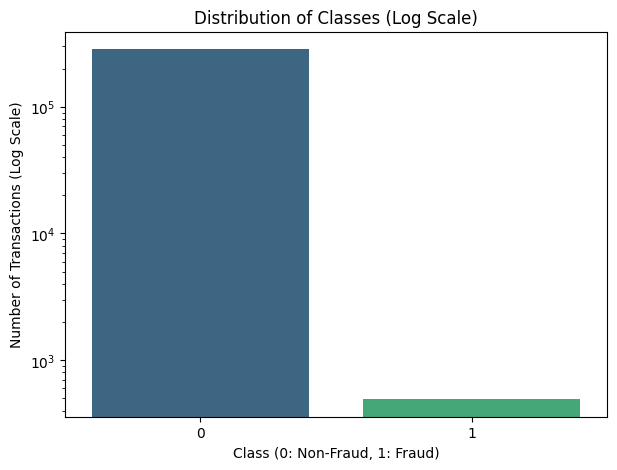

In [ ]:
# Using a logarithmic scale to show the imbalance well
plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette=palette, legend=False)

plt.title("Distribution of Classes (Log Scale)")
plt.xlabel("Class (0: Non-Fraud, 1: Fraud)")
plt.ylabel("Number of Transactions (Log Scale)")
plt.xticks(ticks=[0, 1], labels=["0", "1"], rotation=0) # Ensure labels are clear
plt.yscale("log") # Apply logarithmic scale to the y-axis
plt.show()

### Data Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data["Amount"] = scaler.fit_transform(data["Amount"].values.reshape(-1,1)) # Scale the Amount column as all other columns are already scaled
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.350151,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,-0.254117,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,-0.081839,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.313249,0


In [ ]:
data = data.drop(["Time"], axis=1) # To drop the time column as it doesn't affect the classes
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [ ]:
data.duplicated().any() # To check if there is any duplicate in the dataset

np.True_

In [ ]:
data.duplicated().sum()

np.int64(9144)

In [ ]:
data = data.drop_duplicates() # To drop all duplicate rows in the dataset

In [ ]:
data.duplicated().any()

np.False_

In [ ]:
data["Class"].value_counts()

,count
Class,
0,275190
1,473


### *Plots After dropping duplicates*

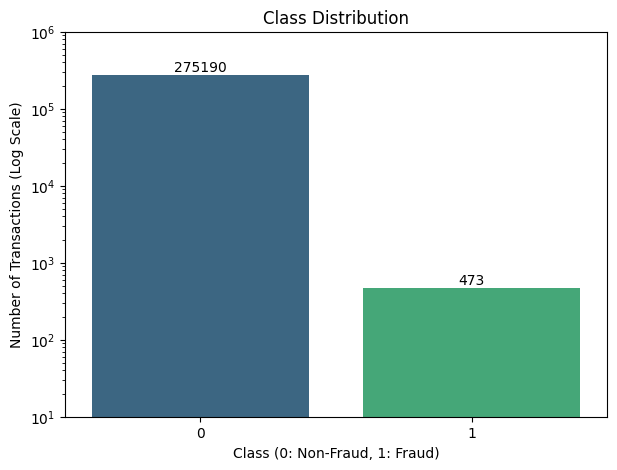

In [ ]:
def plot_class_distribution(y, title="Class Distribution"):

    new_class_counts = y.value_counts().sort_index()

    plt.figure(figsize=(7, 5))
    ax = sns.barplot(
        x=new_class_counts.index,
        y=new_class_counts.values,
        hue=new_class_counts.index,
        palette="viridis",
        dodge=False,
        legend=False
    )

    plt.title(title)
    plt.xlabel("Class (0: Non-Fraud, 1: Fraud)")
    plt.ylabel("Number of Transactions (Log Scale)")
    plt.xticks(new_class_counts.index, new_class_counts.index.astype(str))
    plt.yscale("log") # Apply logarithmic scale to the y-axis
    plt.ylim(10, 10**6) # Set y-axis limits from 10^1 to 10^6

    # Add counts above bars
    for bar in ax.patches:
        height = bar.get_height()
        ax.annotate(
            f'{int(height)}',
            (bar.get_x() + bar.get_width()/2, height),
            ha="center", va="bottom", fontsize=10
        )

    plt.show()

plot_class_distribution(data["Class"], "Class Distribution")

### *Feature-Label Separation*

In [ ]:
# Separating our data into features and labels respectively
X = data.drop("Class", axis=1)
y = data["Class"]

In [ ]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.350151
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,-0.254117
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,-0.081839
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.313249


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Set the final test set for checking the metrics for all cases

In [ ]:
final_X_test = X_test.copy()
final_y_test = y_test.copy()

In [ ]:
# For visualization
temp_X_train = X_train.copy()
temp_X_test = X_test.copy()
temp_y_train = y_train.copy()

### *Visualization of the Imbalanced dataset using PCA*

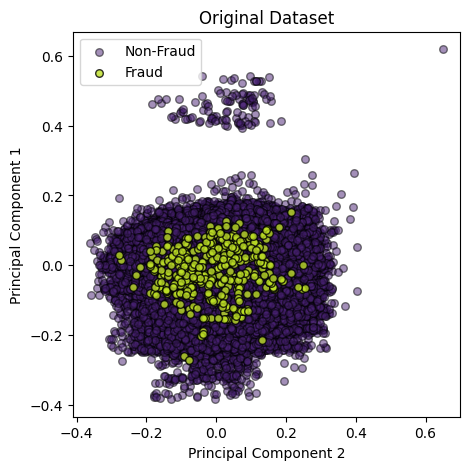

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# Helper function to use PCA to visualize the training data
def pca_visualize(pass_X_train, pass_X_test, pass_y_train, description):
  scaler = MinMaxScaler()
  scaler.fit(pass_X_train)
  pass_X_train = scaler.transform(pass_X_train)
  pass_X_test = scaler.transform(pass_X_test)

  # Perform PCA Decomposition on both train and test sets
  # Note that we fit PCA on X_train only, not on the entire dataset.
  # This prevents data leakage from test set to train set.
  pca = PCA(n_components=2)
  pca.fit(pass_X_train)
  X_train_pca = pca.transform(pass_X_train)
  X_test_pca = pca.transform(pass_X_test)

  # Function for plotting dataset
  def plot_data(X,y,ax,title):
      # Separate data by class
      X_non_fraud = X[y == 0]
      X_fraud = X[y == 1]

      # Plot Non-Fraud (Normal) in purple
      ax.scatter(X_non_fraud[:, 0], X_non_fraud[:, 1], color="#482173", alpha=0.5, s = 30, edgecolor=(0,0,0,0.5), label="Non-Fraud")

      # Plot Fraud in yellow
      ax.scatter(X_fraud[:, 0], X_fraud[:, 1], color="#bddf26", alpha=0.8, s = 30, edgecolor=(0,0,0,0.5), label="Fraud") # Increased alpha for better visibility

      ax.set_ylabel("Principal Component 1")
      ax.set_xlabel("Principal Component 2")
      if title is not None:
          ax.set_title(title)
      ax.legend() # Add the legend

  # Plot dataset
  fig,ax = plt.subplots(figsize=(5, 5))
  plot_data(X_train_pca, pass_y_train, ax, title=description)
  plt.show()


pca_visualize(temp_X_train, temp_X_test, temp_y_train, "Original Dataset")

In [ ]:
temp_X_train

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
85263,-0.204719,0.230561,0.585213,-1.042216,0.523612,-0.813961,0.521473,-0.349696,-1.985971,0.391029,-0.855039,-0.434753,1.755244,-0.261701,0.453370,0.522140,0.274152,-1.231296,1.763844,0.428518,0.295196,0.769031,-0.295086,-0.358231,0.191942,-0.015486,0.104205,0.127050,-0.253277
87877,-1.536222,1.076634,1.158729,-1.014278,0.303728,-1.434520,0.880383,0.199717,-0.694732,-1.185566,-0.844735,-0.163320,-0.552837,0.559061,-0.347562,0.676268,-0.701437,-0.423165,-1.587533,-0.427334,0.020621,-0.183758,-0.104223,0.380524,0.767783,0.125901,-0.293290,-0.056513,-0.339556
199987,0.180614,1.100063,-1.022411,0.003125,0.208371,-1.445858,0.602641,0.118823,-0.112330,-1.122496,-0.704963,-0.247830,-0.307998,-0.452348,0.683835,0.222439,0.609756,0.754601,-0.255332,-0.240878,0.331292,0.920748,-0.059538,-0.033873,-0.277221,-0.151729,-0.074708,-0.046507,-0.268150
92683,-0.090912,0.770375,1.106896,0.000738,0.843993,0.130005,0.816123,-0.311543,-0.209850,0.236914,0.399226,-0.717905,-1.109598,-0.372682,0.795542,0.527669,-0.573767,0.949729,1.355919,0.131621,-0.287096,-0.616660,-0.176805,-0.910379,-0.722550,0.077614,-0.335306,-0.300600,-0.345313
198830,-0.256459,1.085422,-0.698082,-1.339884,1.567292,-0.964274,1.967021,-1.024060,0.361965,1.129291,1.169806,0.145470,-0.714166,0.067899,-0.544712,-0.701108,-0.963824,0.001249,0.131164,0.213442,0.092316,0.760264,-0.335504,0.795715,0.181275,-0.002008,-0.748489,-0.564823,-0.337837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97837,1.070935,-0.037082,0.241227,0.925096,-0.149776,0.075161,-0.108900,0.188041,0.025005,0.140503,1.015712,0.127794,-1.429812,0.832557,0.760632,0.247258,-0.484105,0.173280,-0.324083,-0.137749,0.018009,-0.105977,-0.070361,-0.350878,0.415994,-0.407009,0.015682,0.014533,-0.133375
121479,-0.997543,0.347922,0.672391,-3.161061,2.255887,3.202902,-0.012360,1.041808,-0.051911,-1.046102,-0.299417,-0.270323,-0.112547,-0.107163,0.428542,1.492264,-1.509408,0.050510,-1.163178,0.155870,-0.171719,-0.734021,-0.183943,1.038217,0.312299,1.025546,0.140068,0.099066,-0.281304
58422,-2.790771,-1.464269,1.031165,1.921356,-0.090014,-0.483871,0.780731,-0.348776,0.609133,0.225934,-1.064534,-0.787373,-1.576470,-0.126756,0.367012,-0.635322,0.327006,0.043816,1.403574,-1.376721,-0.392667,0.440020,0.777659,0.418552,0.244563,-0.159361,0.060540,0.356958,0.480691
52733,-1.662420,0.356751,1.008239,0.918071,0.763411,-0.707249,0.611923,-0.195329,0.350152,1.004746,-0.322524,-0.748812,-1.194287,0.143316,1.566447,-0.626770,-0.011622,-0.278069,0.115921,-0.182086,-0.166567,0.580435,0.463189,0.057710,-0.062059,-0.267911,0.594420,0.007228,-0.335838


# Imbalanced Data
We'll make use of SVMs, Decision Trees, and Random Forest Classifiers

### *Run all three models at once*

In [ ]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



In [ ]:
import time

# Helper function to run all 3 models and return the dataframe containing the metrics
def run_all_models(X_new, y_new):
  acc_list = []
  rec_list = []
  prec_list = []
  f1_list = []
  time_list = [] # To store computation time
  predictions = {}

  svm_clf = SVC()
  tree_clf = DecisionTreeClassifier()
  forest_clf = RandomForestClassifier()

  # A list of (classifier, name) tuples
  classifiers = [
      (svm_clf, "Support Vector Machines"),
      (tree_clf, "Decision Trees"),
      (forest_clf, "Random Forest")
  ]

  for clf, name in classifiers:
    start_time = time.time() # Record start time
    clf.fit(X_new, y_new)
    y_pred = clf.predict(final_X_test)
    end_time = time.time() # Record end time
    time_list.append(end_time - start_time) # Calculate and store computation time

    # Append all scores to their respective metrics
    acc_list.append(accuracy_score(final_y_test, y_pred))
    rec_list.append(recall_score(final_y_test, y_pred))
    prec_list.append(precision_score(final_y_test, y_pred))
    f1_list.append(f1_score(final_y_test, y_pred))
    predictions[name] = y_pred # Store predictions

  print(time_list)

  # create a new dataframe
  visual_data = pd.DataFrame({"Models": [name for _, name in classifiers], "ACC": acc_list, "PRE": prec_list, "REC": rec_list, "F1": f1_list})
  return visual_data, predictions # Return both dataframe and predictions

In [ ]:
imbalanced_metrics, imbalanced_predictions_dict = run_all_models(X_train, y_train)
imbalanced_metrics

[353.55665373802185, 32.44584631919861, 385.55799436569214]


,Models,ACC,PRE,REC,F1
0,Support Vector Machines,0.999256,0.909091,0.631579,0.745342
1,Decision Trees,0.999075,0.744444,0.705263,0.724324
2,Random Forest,0.999456,0.922078,0.747368,0.825581


In [ ]:
imbalanced_metrics

,Models,ACC,PRE,REC,F1
0,Support Vector Machines,0.999256,0.909091,0.631579,0.745342
1,Decision Trees,0.999039,0.728261,0.705263,0.716578
2,Random Forest,0.999438,0.921053,0.736842,0.818713


### *Visualizing the metrics for the models for the imbalanced data*

In [ ]:
# Helper function to plot the comparison barplot

def model_performance_barplot(df_metrics, description):

  df_metrics_long = pd.melt(
      df_metrics,
      id_vars=["Models"],
      value_vars=["ACC", "PRE", "REC", "F1"],
      var_name="Metric",
      value_name="Score"
  )

  # Map abbreviations to full names for the legend
  metric_names = {
      "ACC": "Accuracy",
      "PRE": "Precision",
      "REC": "Recall",
      "F1": "F1-Score"
  }
  df_metrics_long["Metric"] = df_metrics_long["Metric"].map(metric_names)

  plt.figure(figsize=(12, 6))
  sns.barplot(
    x="Models",
    y="Score",
    hue="Metric",
    data=df_metrics_long,
    palette="viridis"
  )

  plt.title(description, fontsize=16)
  plt.ylabel("Score", fontsize=12)
  plt.xlabel("Model", fontsize=12)
  plt.ylim(0, 1.0)
  plt.legend(title="Metrics")

  plt.tight_layout()
  plt.show()

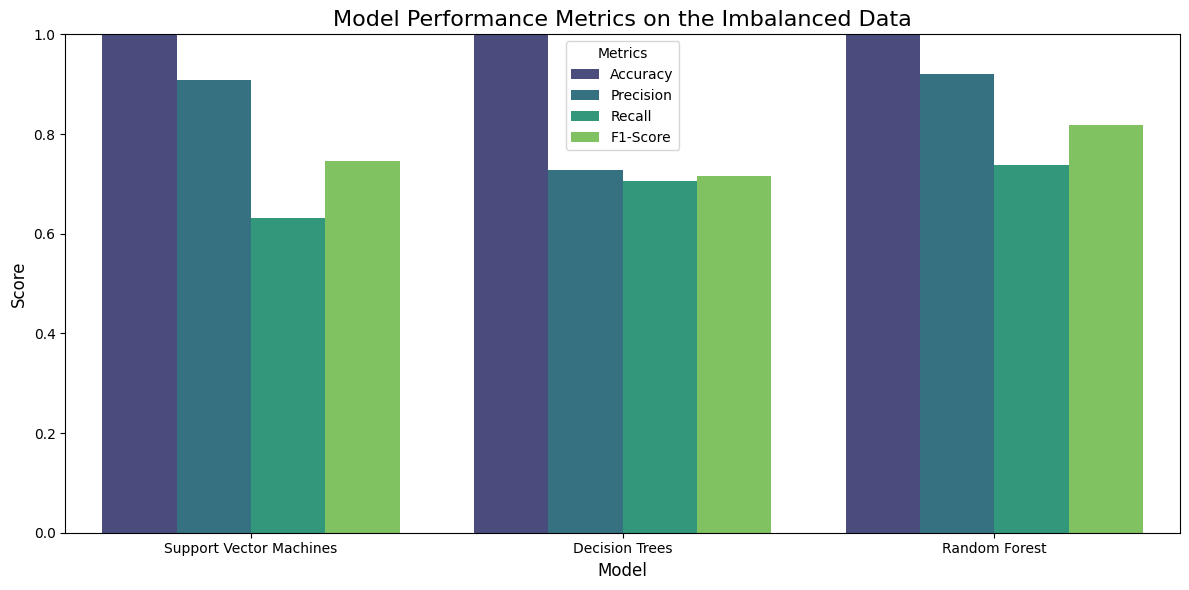

In [ ]:
model_performance_barplot(imbalanced_metrics, "Model Performance Metrics on the Imbalanced Data")

# Undersampled Data

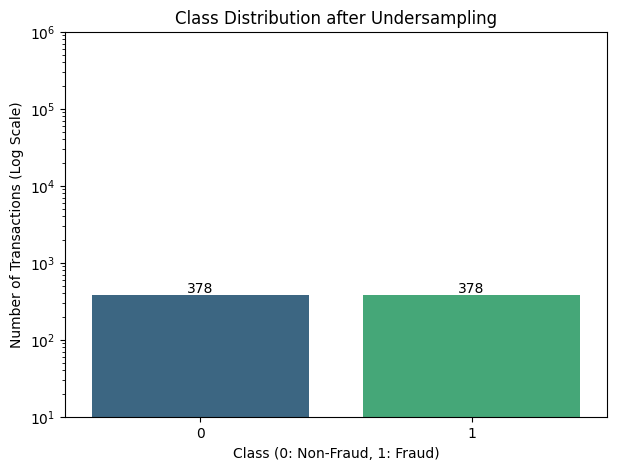

In [ ]:
plot_class_distribution(y_rus, "Class Distribution after Undersampling")

### *Classifying the Undersampled Dataset*

In [ ]:
undersampled_metrics, undersampled_predictions_dict = run_all_models(X_rus, y_rus)
undersampled_metrics

[0.7096264362335205, 0.03184914588928223, 0.7170634269714355]


,Models,ACC,PRE,REC,F1
0,Support Vector Machines,0.982860,0.082515,0.884211,0.150943
1,Decision Trees,0.909310,0.016749,0.894737,0.032882
2,Random Forest,0.976149,0.061782,0.905263,0.115669


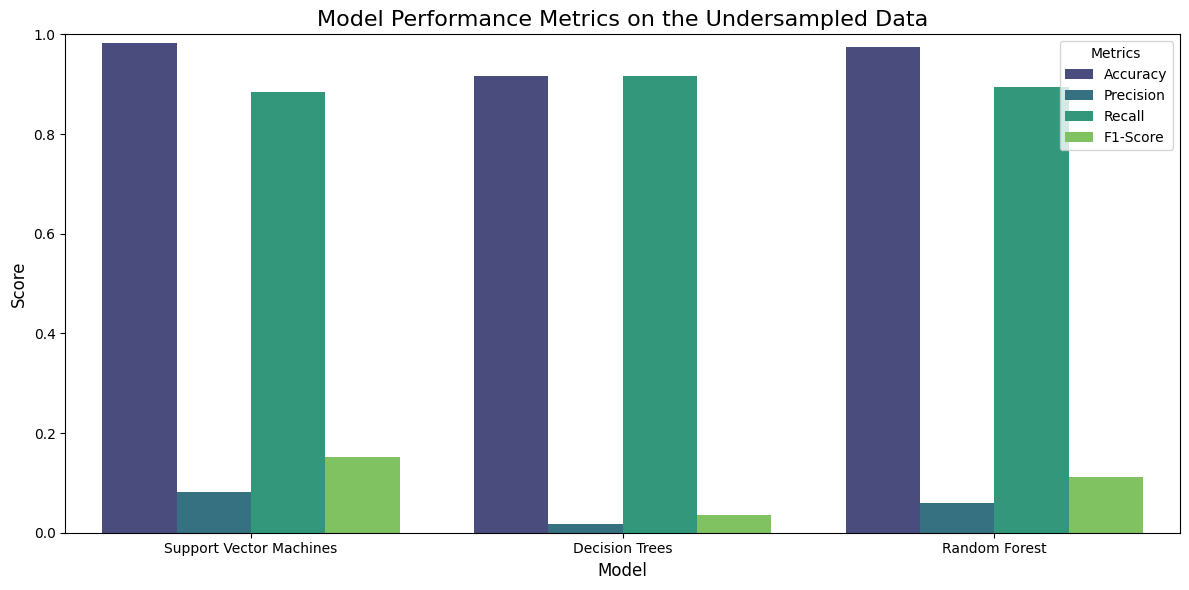

In [ ]:
model_performance_barplot(undersampled_metrics, "Model Performance Metrics on the Undersampled Data")

# Oversampled Data with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

In [ ]:
y_smote.value_counts()

,count
Class,
0,220152
1,220152


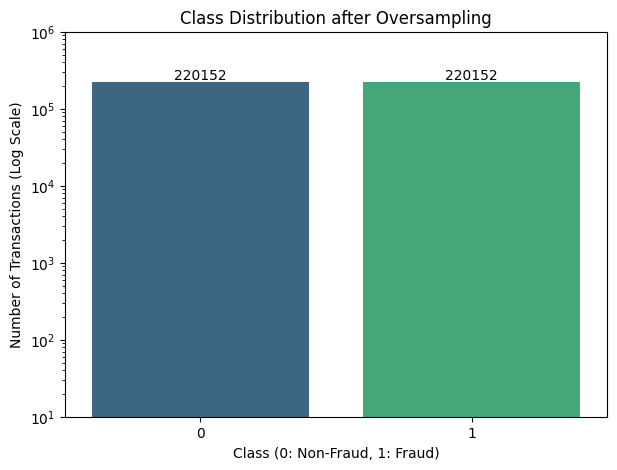

In [ ]:
plot_class_distribution(y_smote, "Class Distribution after Oversampling")

In [ ]:
oversampled_metrics, oversampled_predictions_dict = run_all_models(X_smote, y_smote)
oversampled_metrics

[1997.0539512634277, 69.6287693977356, 659.0641233921051]


,Models,ACC,PRE,REC,F1
0,Support Vector Machines,0.985308,0.090493,0.831579,0.163223
1,Decision Trees,0.997388,0.368984,0.726316,0.489362
2,Random Forest,0.999347,0.831461,0.778947,0.804348


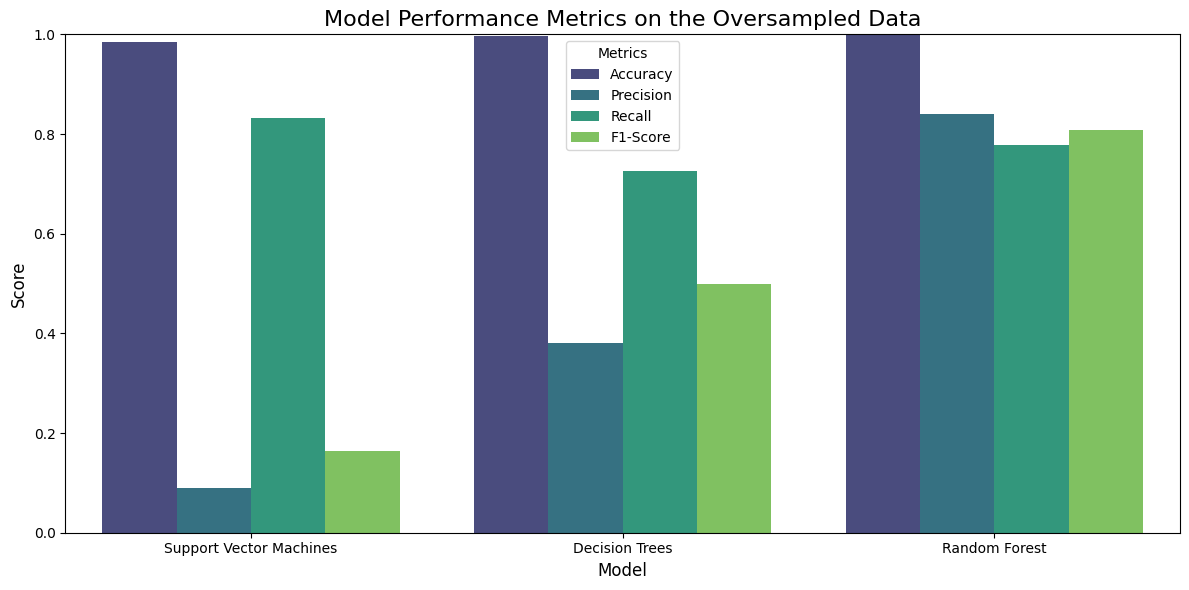

In [ ]:
model_performance_barplot(oversampled_metrics, "Model Performance Metrics on the Oversampled Data")

# Implementing Class weighing (with imbalanced, undersampled, and oversampled data)

In [ ]:
# Helper function to run all 3 models and return the dataframe containing the metrics
def run_all_models_with_cost_weighting(X_new, y_new):
  acc_list = []
  rec_list = []
  prec_list = []
  f1_list = []
  time_list = []
  predictions = {} # Add this to store predictions

 # Cost-weighted Models
  svm_clf = SVC(class_weight="balanced")
  tree_clf_weighted = DecisionTreeClassifier(class_weight="balanced")
  forest_clf = RandomForestClassifier(class_weight="balanced_subsample")

  classifiers = [
      (svm_clf, "Support Vector Machines"),
      (tree_clf_weighted, "Decision Trees"),
      (forest_clf, "Random Forest")
  ]

  for clf, name in classifiers:
    start_time = time.time() # Record start time
    clf.fit(X_new, y_new)
    y_pred = clf.predict(final_X_test)
    end_time = time.time() # Record end time
    time_list.append(end_time - start_time) # Calculate and store computation time


    # Append all scores to their respective metrics
    acc_list.append(accuracy_score(final_y_test, y_pred))
    rec_list.append(recall_score(final_y_test, y_pred))
    prec_list.append(precision_score(final_y_test, y_pred))
    f1_list.append(f1_score(final_y_test, y_pred))
    predictions[name] = y_pred # Store predictions

  print(time_list)

  # create a new dataframe
  visual_data = pd.DataFrame({
      "Models": [name for _, name in classifiers],
      "ACC": acc_list,
      "PRE": prec_list,
      "REC": rec_list,
      "F1": f1_list,
  })
  return visual_data, predictions # Return both dataframe and predictions

### Running Class weighted models on the full dataest

In [ ]:
imbalanced_metrics_weighted, imbalanced_weighted_predictions_dict = run_all_models_with_cost_weighting(X_train, y_train)
display(imbalanced_metrics_weighted)

[201.21996808052063, 15.112634420394897, 212.61107730865479]


,Models,ACC,PRE,REC,F1
0,Support Vector Machines,0.996391,0.281513,0.705263,0.402402
1,Decision Trees,0.998930,0.719512,0.621053,0.666667
2,Random Forest,0.999401,0.918919,0.715789,0.804734


In [ ]:
undersampled_metrics_weighted, undersampled_weighted_predictions_dict = run_all_models_with_cost_weighting(X_rus, y_rus)
display(undersampled_metrics_weighted)

[1.214860439300537, 0.04597353935241699, 1.1313374042510986]


,Models,ACC,PRE,REC,F1
0,Support Vector Machines,0.982860,0.082515,0.884211,0.150943
1,Decision Trees,0.915477,0.017951,0.894737,0.035197
2,Random Forest,0.974008,0.056366,0.894737,0.106051


In [ ]:
oversampled_metrics_weighted, oversampled_weighted_predictions_dict = run_all_models_with_cost_weighting(X_smote, y_smote)
display(oversampled_metrics_weighted)

[2082.817608356476, 77.239821434021, 680.1030974388123]


,Models,ACC,PRE,REC,F1
0,Support Vector Machines,0.985308,0.090493,0.831579,0.163223
1,Decision Trees,0.997533,0.386740,0.736842,0.507246
2,Random Forest,0.999365,0.840909,0.778947,0.808743


# More Visualization for the poster

### Visualizing Model Performance Metrics on Oversampled Data with Class Weighing

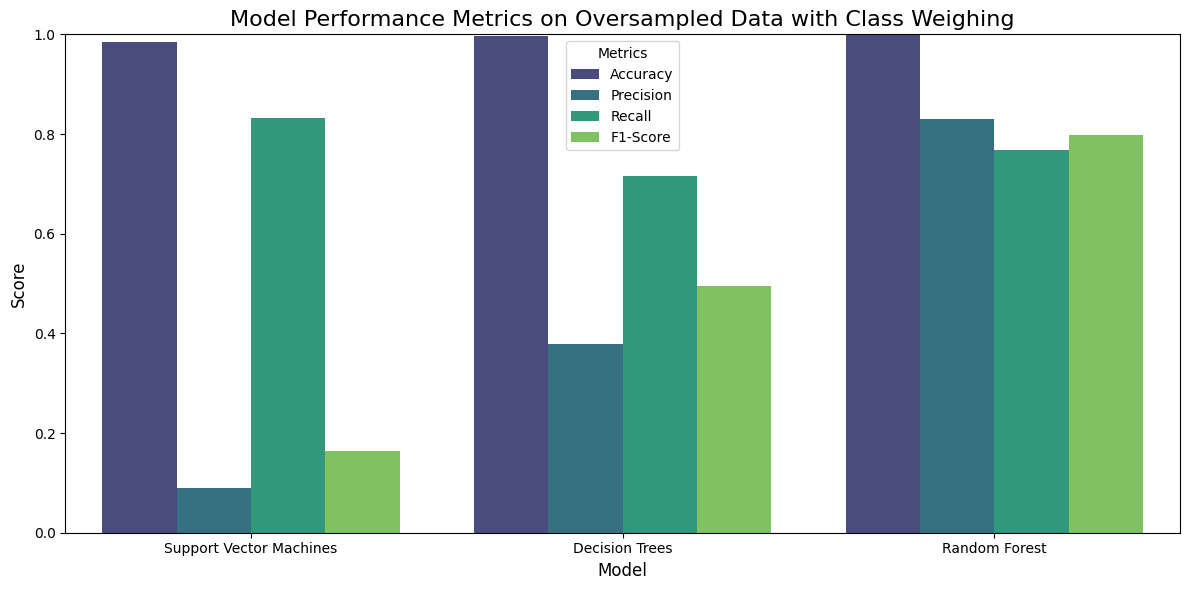

In [ ]:
model_performance_barplot(oversampled_metrics_weighted, "Model Performance Metrics on Oversampled Data with Class Weighing")

### Confusion Matrices for Imbalanced Data

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

def plot_confusion_matrix(y_true, y_pred, model_name, ax):
  """Plots a confusion matrix with 4 distinct colors for quadrants."""
  cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

  # User-provided colors for TN, FP, FN, TP respectively
  custom_colors = ["#455681", "#2F837F", "#6CBD6F", "#00246B"]

  # Create a dummy matrix for coloring purposes, where each quadrant gets a unique index (0-3).
  # This allows assigning a specific color to each quadrant.
  color_index_matrix = np.array([[0, 1], [2, 3]]) # TN=0, FP=1, FN=2, TP=3

  # Create a custom colormap from the distinct custom colors
  cmap_custom = mcolors.ListedColormap(custom_colors)

  sns.heatmap(
      color_index_matrix, # Use this matrix for coloring based on index
      annot=cm,           # Annotate with the actual confusion matrix values
      fmt="d",            # Format annotations as integers
      cmap=cmap_custom,
      linewidths=.5,
      linecolor="black",
      cbar=False,         # No color bar needed as colors are categorical
      ax=ax,
      square=True
  )

  ax.set_title(f"Confusion Matrix - {model_name}", fontsize=12)
  ax.set_xlabel("Predicted label", fontsize=10)
  ax.set_ylabel('True label', fontsize=10)
  ax.set_xticks([0.5, 1.5], ["0", "1"], ha="center") # Center labels for 0 and 1
  ax.set_yticks([0.5, 1.5], ["0", "1"], va="center", rotation=90)



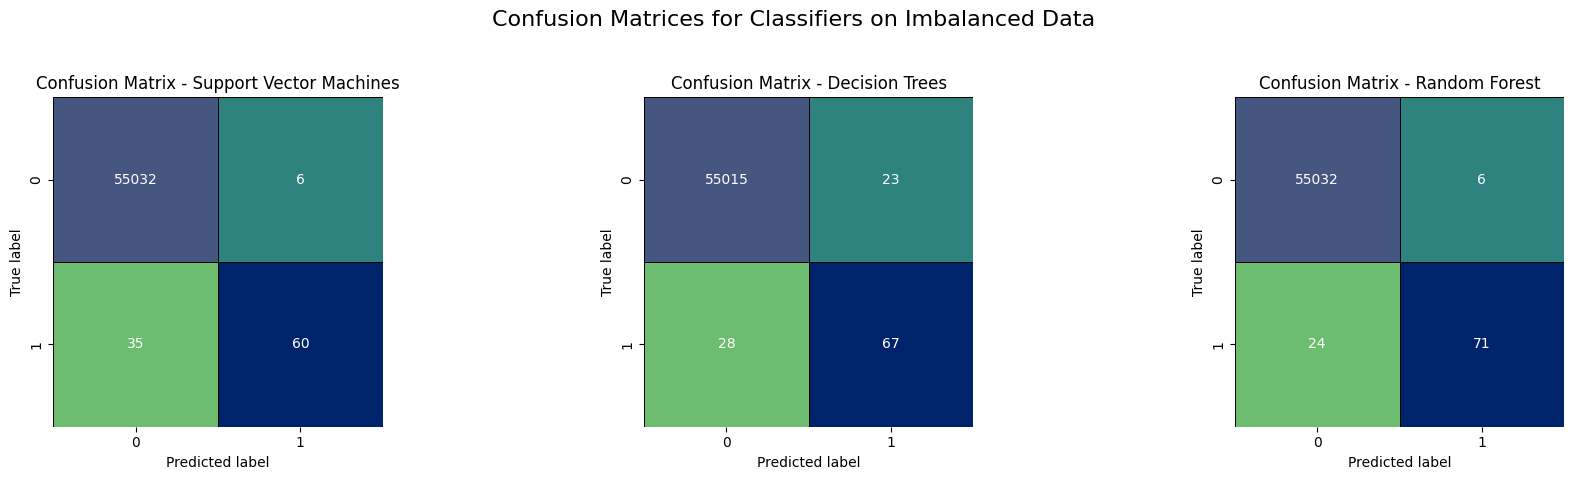

In [ ]:
# Plot Confusion Matrices for imbalanced data
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Confusion Matrices for Classifiers on Imbalanced Data", fontsize=16)

for i, (model_name, y_pred) in enumerate(imbalanced_predictions_dict.items()):
  plot_confusion_matrix(final_y_test, y_pred, model_name, axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()